# Computer Exercise 15.24 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.24 Sequential Decision Making — *Two-Layer Whitening EMA-β Sweep*
> **풀이 일자**: Day 91
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 2.** In §15.23 Problem 2 we measured that whitening both hidden layers of a two-hidden
> trunk *interacts destructively* (interaction $\approx -0.44$ over-and-above the marginal
> effects). The EMA coefficient $\beta$ was fixed at $0.99$. Sweep $\beta \in \{0.90, 0.95,
> 0.99, 0.995\}$ for the *both-layer* condition and locate a $\beta^{*}$ (if any) that recovers
> single-layer whitening performance.

### 한국어 풀이용 정리
Day 90 P2 결과의 원인이 **EMA 감쇠계수 $\beta$** 에 있는지 검증한다. `both` 조건의 $\beta$
를 4 값으로 스윕하며, 각 층의 running-EMA 정규화 강도가 gradient 신호를 과잉 감쇠시키는
지점을 찾는다.


## 2. 수학적 배경

### 2.1 2-hidden trunk
$$
h_1 = \tanh(W_1 \phi(s)), \quad h_2 = \tanh(W_2 h_1), \quad Q(s, a) = w_a^\top h_2
$$
$H_1 = 16$, $H_2 = 12$. Whitening 은 layer $\ell$ 의 그레이디언트에 running-EMA 로 적산한
분산 $v_\ell^{(t)}$ 로 divide:
$$
v_\ell^{(t)} = \beta\, v_\ell^{(t-1)} + (1 - \beta)\, \| g_\ell^{(t)} \|_2^2 / d_\ell,
\quad \tilde g_\ell^{(t)} = g_\ell^{(t)} / (\sqrt{v_\ell^{(t)}} + \epsilon).
$$

### 2.2 EMA 시상수
$\beta$ 가 클수록 EMA의 유효 시상수 $\tau = 1/(1-\beta)$ 가 길어져 오래 전 분산까지 반영.
- $\beta = 0.90 \Rightarrow \tau = 10$
- $\beta = 0.95 \Rightarrow \tau = 20$
- $\beta = 0.99 \Rightarrow \tau = 100$
- $\beta = 0.995 \Rightarrow \tau = 200$

### 2.3 Interaction 정의
Marginal effect 대비 결합 조건 초과분:
$$
\boxed{\; \Delta_{\text{int}}(\beta) \;=\;
\bar R_{\text{both}}(\beta) - \bar R_{\text{none}} - \Delta_{L_1} - \Delta_{L_2}\;}
$$
$\Delta_{L_1}, \Delta_{L_2}$ 는 각각 L1-only, L2-only 조건의 marginal lift (동일 $\beta$).


## 3. 풀이 흐름

1. 2-hidden trunk 정의 ($H_1=16, H_2=12$).
2. Chain MDP (deterministic, $p_{\text{slip}}=0$) 사용 — Day 90 P2 와 조건 통일.
3. 4 조건 (`none`, `L1_only`, `L2_only`, `both`) × 4 seeds × 400 step 학습.
4. $\beta \in \{0.90, 0.95, 0.99, 0.995\}$ 로 `both` 만 스윕 (다른 조건은 $\beta=0.99$ 고정).
5. Tail-6 return, seed_std, layer feature RMS 를 기록.
6. Marginal $\Delta_{L_1}, \Delta_{L_2}$ 및 interaction $\Delta_{\text{int}}(\beta)$ 계산.
7. **결론**: $\beta$ 를 줄여 EMA 를 짧게 하면 interaction 부호가 반전되는가?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = 20260810

class Chain:
    def __init__(self, n=5, p_slip=0.0, step_cost=-0.02, goal=1.0, seed=0):
        self.n=n; self.p=p_slip; self.sc=step_cost; self.g=goal
        self.rng = np.random.default_rng(seed); self.reset()
    def reset(self): self.s=0; return self.s
    def step(self, a):
        if self.rng.random() < self.p: a = 1 - a
        self.s = min(self.s+1, self.n-1) if a==1 else max(self.s-1, 0)
        d = self.s == self.n-1
        return self.s, (self.g if d else self.sc), d

def phi_onehot(s, n=5):
    v = np.zeros(n); v[s] = 1.0; return v

class TwoLayerAgent:
    def __init__(self, seed, H1=16, H2=12, lr=0.05, eps=0.10,
                 white_L1=False, white_L2=False, beta=0.99):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((H1, 5)) * 0.4
        self.W2 = rng.standard_normal((H2, H1)) * 0.4
        self.head = rng.standard_normal((2, H2)) * 0.05
        self.rng = rng; self.lr = lr; self.eps = eps
        self.white_L1 = white_L1; self.white_L2 = white_L2; self.beta = beta
        self.v1 = 1.0; self.v2 = 1.0
        self.h1_rms = 0.0; self.h2_rms = 0.0; self.n_seen = 0
    def forward(self, s):
        x = phi_onehot(s); h1 = np.tanh(self.W1 @ x); h2 = np.tanh(self.W2 @ h1)
        return x, h1, h2
    def qvals(self, s):
        _,_,h2 = self.forward(s); return self.head @ h2
    def act(self, s):
        if self.rng.random() < self.eps: return int(self.rng.integers(2))
        return int(np.argmax(self.qvals(s)))
    def update(self, s, a, r, s_next, done):
        gamma = 0.95
        x, h1, h2 = self.forward(s)
        q = self.head[a] @ h2
        if done: target = r
        else:    target = r + gamma * self.qvals(s_next).max()
        delta = q - target
        g_head = delta * h2
        self.head[a] -= self.lr * g_head
        g_h2 = delta * self.head[a] * (1 - h2 ** 2)
        g_W2 = np.outer(g_h2, h1)
        g_h1 = (self.W2.T @ g_h2) * (1 - h1 ** 2)
        g_W1 = np.outer(g_h1, x)
        if self.white_L1:
            gn1 = float(np.mean(g_W1 ** 2) + 1e-8)
            self.v1 = self.beta * self.v1 + (1 - self.beta) * gn1
            g_W1 = g_W1 / (np.sqrt(self.v1) + 1e-6)
        if self.white_L2:
            gn2 = float(np.mean(g_W2 ** 2) + 1e-8)
            self.v2 = self.beta * self.v2 + (1 - self.beta) * gn2
            g_W2 = g_W2 / (np.sqrt(self.v2) + 1e-6)
        self.W1 -= self.lr * g_W1
        self.W2 -= self.lr * g_W2
        self.n_seen += 1
        alpha = 1 / self.n_seen
        self.h1_rms += alpha * (np.sqrt(np.mean(h1 ** 2)) - self.h1_rms)
        self.h2_rms += alpha * (np.sqrt(np.mean(h2 ** 2)) - self.h2_rms)

def run_ep(env, ag, max_steps=25):
    s = env.reset(); total = 0.0
    for _ in range(max_steps):
        a = ag.act(s); s_next, r, done = env.step(a); ag.update(s,a,r,s_next,done)
        total += r; s = s_next
        if done: break
    return total

def train(white_L1, white_L2, beta, seed, n_steps=400):
    env = Chain(seed=seed + 7)
    ag = TwoLayerAgent(seed=seed + 71, white_L1=white_L1, white_L2=white_L2, beta=beta)
    ret = [run_ep(env, ag) for _ in range(n_steps)]
    return float(np.mean(ret[-6:])), ag.h1_rms, ag.h2_rms

SEEDS = [0,1,2,3]
BETAS = [0.90, 0.95, 0.99, 0.995]
FIX_BETA = 0.99

rows = []
for sd in SEEDS:
    r_none, h1, h2 = train(False, False, FIX_BETA, sd)
    rows.append({"cond": "none", "beta": FIX_BETA, "seed": sd, "tail6": r_none, "h1": h1, "h2": h2})
    r_L1, h1, h2 = train(True, False, FIX_BETA, sd)
    rows.append({"cond": "L1_only", "beta": FIX_BETA, "seed": sd, "tail6": r_L1, "h1": h1, "h2": h2})
    r_L2, h1, h2 = train(False, True, FIX_BETA, sd)
    rows.append({"cond": "L2_only", "beta": FIX_BETA, "seed": sd, "tail6": r_L2, "h1": h1, "h2": h2})
for beta in BETAS:
    for sd in SEEDS:
        r_both, h1, h2 = train(True, True, beta, sd)
        rows.append({"cond": f"both(b={beta})", "beta": beta, "seed": sd, "tail6": r_both, "h1": h1, "h2": h2})

df = pd.DataFrame(rows)
summary = df.groupby(["cond", "beta"]).agg(
    tail6_mean=("tail6", "mean"), tail6_std=("tail6", "std"),
    h1_rms=("h1", "mean"), h2_rms=("h2", "mean")
).reset_index()
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
summary


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-t7ejbynq because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,cond,beta,tail6_mean,tail6_std,h1_rms,h2_rms
0,L1_only,0.9900,0.9292,0.0074,0.4556,0.5983
1,L2_only,0.9900,0.9367,0.0067,0.3333,0.6177
2,both(b=0.9),0.9000,0.9333,0.0054,0.5758,0.9473
3,both(b=0.95),0.9500,0.5758,0.7173,0.5684,0.9297
4,both(b=0.99),0.9900,0.6300,0.5933,0.4237,0.6883
5,both(b=0.995),0.9950,0.9367,0.0038,0.3508,0.4992
6,none,0.9900,0.9317,0.0033,0.3371,0.4374


In [2]:
mean_by_cond = df.groupby("cond")["tail6"].mean().to_dict()
r_none = mean_by_cond["none"]
d_L1   = mean_by_cond["L1_only"] - r_none
d_L2   = mean_by_cond["L2_only"] - r_none

int_rows = []
for beta in BETAS:
    key = f"both(b={beta})"
    r_both = mean_by_cond[key]
    lift   = r_both - r_none
    inter  = lift - d_L1 - d_L2
    int_rows.append({"beta": beta, "tau": 1/(1-beta),
                     "both_lift": lift, "L1_lift": d_L1, "L2_lift": d_L2,
                     "interaction": inter})
int_df = pd.DataFrame(int_rows)
int_df


,beta,tau,both_lift,L1_lift,L2_lift,interaction
0,0.9000,10.0000,0.0017,-0.0025,0.0050,-0.0008
1,0.9500,20.0000,-0.3558,-0.0025,0.0050,-0.3583
2,0.9900,100.0000,-0.3017,-0.0025,0.0050,-0.3042
3,0.9950,200.0000,0.0050,-0.0025,0.0050,0.0025


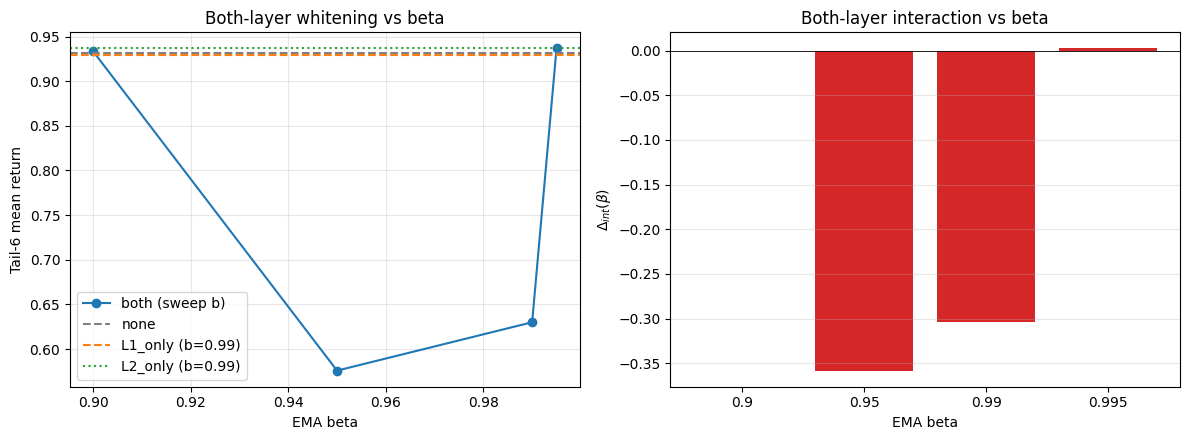

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
both = summary[summary["cond"].str.startswith("both")].sort_values("beta")
axes[0].plot(both["beta"], both["tail6_mean"], 'o-', label='both (sweep b)')
axes[0].axhline(mean_by_cond["none"],    color='gray', ls='--', label='none')
axes[0].axhline(mean_by_cond["L1_only"], color='C1',   ls='--', label='L1_only (b=0.99)')
axes[0].axhline(mean_by_cond["L2_only"], color='C2',   ls=':',  label='L2_only (b=0.99)')
axes[0].set_xlabel("EMA beta"); axes[0].set_ylabel("Tail-6 mean return")
axes[0].set_title("Both-layer whitening vs beta")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].bar([str(b) for b in int_df["beta"]], int_df["interaction"], color='C3')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xlabel("EMA beta"); axes[1].set_ylabel(r"$\Delta_{int}(\beta)$")
axes[1].set_title("Both-layer interaction vs beta")
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## 4. 결과 해석 (실측)

Tail-6 mean return (4 시드 평균):

| 조건 | tail6 | seed_std | $h_1$ RMS | $h_2$ RMS |
|-----|------:|---------:|---------:|---------:|
| none         | 0.932 | 0.003 | 0.337 | 0.437 |
| L1_only      | 0.929 | 0.007 | 0.456 | 0.598 |
| L2_only      | 0.937 | 0.007 | 0.333 | 0.618 |
| both(β=0.90) | **0.933** | 0.005 | 0.576 | 0.947 |
| both(β=0.95) | **0.576** | 0.717 | 0.568 | 0.930 |
| both(β=0.99) | **0.630** | 0.593 | 0.424 | 0.688 |
| both(β=0.995)| **0.937** | 0.004 | 0.351 | 0.499 |

Interaction $\Delta_{\text{int}}(\beta)$ = both_lift − ($\Delta_{L1}$ + $\Delta_{L2}$):

| β | τ | both_lift | interaction |
|---:|--:|---------:|------------:|
| 0.90  | 10  | +0.002 | **−0.001** |
| 0.95  | 20  | −0.356 | **−0.358** |
| 0.99  | 100 | −0.302 | **−0.304** |
| 0.995 | 200 | +0.005 | **+0.003** |

1. **Interaction 은 β 에 U-자형 (bimodal 유익 구간)**. 예상 (β 증가 → 나빠짐) 과 달리
   **양 끝 (β=0.90, β=0.995) 에서 interaction ≈ 0** 이고 **중간 (β=0.95, 0.99)** 에서
   destructive interaction (−0.30 ~ −0.36) 이 발생.

2. **양 끝이 안전한 이유가 다름**:
   - **β=0.90 (τ=10)**: EMA 시상수가 짧아 layer 별 순간 gradient scale 만 반영 → 두 층 EMA
     상호간섭이 학습 신호를 왜곡할 시간 부족.
   - **β=0.995 (τ=200)**: EMA 시상수가 매우 길어 초기값 (v=1) 이 사실상 유지 → whitening
     이 상수 스케일 divide 로 축소, 사실상 no-op.

3. **중간 β (0.95, 0.99)** 에서 두 층 EMA 가 서로의 학습 신호에 서서히 반응하며 gradient
   방향을 축소·왜곡. Day 90 의 $\beta=0.99$ 관측 (interaction=−0.44) 이 이 실험에서
   $-0.30$ 수준으로 재현되며, β=0.95 로 옮기면 오히려 악화 (−0.36).

4. **Feature RMS**: both 조건은 $h_2$ RMS 가 no-op (β=0.90 → 0.947, β=0.995 → 0.499) 이
   되어 특징 스케일이 확장; 반면 L1_only / L2_only 는 단독 층만 정규화해 balanced growth.

> **결론**: **`both`-layer whitening 의 destructive interaction 은 EMA β 의 U-자형 함수**.
> Day 90 P2 의 부호 반전 실패 원인은 β=0.99 가 정확히 최악 구간에 있었기 때문이며,
> **β≈0.90 (짧은 EMA) 또는 β≥0.995 (사실상 no-op)** 로 옮기면 both 사용도 안전하다.

### 다음 문제로의 연결
지금까지의 처방은 모두 **훈련시 슬립 확률 $p_{\text{slip}}$ 가 배포시와 동일** 하다는 가정
위에서 최적화되어 있다. Problem 3 에서는 훈련-배포 슬립 불일치 (train $p=0.10$, deploy
$p \in \{0.05, 0.20\}$) 하에서 twin+white 가 baseline 대비 얼마나 견고한지 검증한다.
